# Verification of multimodal base distribution

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

import numpy as np 
import torch
import normflows as nf
from tqdm import tqdm

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt



In [0]:
from mode_assign import *

## Functions

In [0]:
def norm_flow(
    data,
    K,
    hidden,
    layers,
    epoch,
    lam,
    loc,
    scale,
    tail_bound=3,
    num_bins=8,
    test_size=0.2,
    random_state=42,
    torch_seed=42
):
    """
    Trains a normalizing flow model with a Gaussian mixture base distribution.

    Parameters
    ----------
    data : array-like
        Input data.
    K : int
        Number of flow layers (autoregressive spline + ActNorm).
    hidden : int
        Hidden layer size for flow layers.
    layers : int
        Number of layers in each flow block.
    epoch : int
        Number of training epochs.
    lam : float
        Regularization weight for Jacobian penalty.
    loc : list
        Means for each mixture component.
    scale : list
        Scales for each mixture component.
    tail_bound : float, optional
        Tail bound for spline flows.
    num_bins : int, optional
        Number of bins for spline flows.
    test_size : float, optional
        Fraction of data for test split.
    random_state : int, optional
        Random seed for train/test split.
    seed : bool, int, optional
        Random seed for PyTorch.

    Returns
    -------
    mod : nf.NormalizingFlow
        Trained normalizing flow model.
    z_all : np.ndarray
        Latent representations of all data.
    dist_sq : torch.Tensor
        Squared Euclidean distance between latent and input test data.
    """
    torch.manual_seed(torch_seed)
    torch.cuda.manual_seed_all(torch_seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    latent_size = data.shape[1]
    x_train, x_test = train_test_split(
        data, test_size=test_size, random_state=random_state
    )

    scaler = StandardScaler(with_std=False)
    x_train_s = scaler.fit_transform(x_train)
    x_test_s = scaler.transform(x_test)
    x_all_s = scaler.transform(data)

    flows = []
    for _ in range(K):
        flows += [
            nf.flows.AutoregressiveRationalQuadraticSpline(
                latent_size,
                layers,
                hidden,
                permute_mask=True,
                init_identity=True,
                tail_bound=tail_bound,
                num_bins=num_bins
            ),
            # nf.flows.ActNorm(latent_size)
        ]

    q0 = nf.distributions.GaussianMixture(
        n_modes=len(loc),
        dim=latent_size,
        loc=[np.array([loc[i]] * latent_size) for i in range(len(loc))],
        scale=[np.array([scale[i]] * latent_size) for i in range(len(scale))],
        trainable=True,
    )

    mod = nf.NormalizingFlow(q0, flows).to(device)

    x_train_t = torch.tensor(x_train_s, dtype=torch.float32, device=device)
    x_test_t = torch.tensor(x_test, dtype=torch.float32, device=device)
    x_test_s_t = torch.tensor(x_test_s, dtype=torch.float32, device=device)
    x_all_t = torch.tensor(x_all_s, dtype=torch.float32, device=device)

    optimizer = torch.optim.AdamW(mod.parameters(), lr=3e-4)

    mod.train()
    for _ in tqdm(range(epoch), desc="Normalizing flow"):
        optimizer.zero_grad()
        z_train, jac = mod.inverse_and_log_det(x_train_t)
        loss = mod.forward_kld(x_train_t) + lam * torch.mean(jac ** 2)
        if torch.isfinite(loss):
            loss.backward()
            optimizer.step()

    mod.eval()
    with torch.no_grad():
        z_test = mod.inverse(x_test_s_t)
        dist_sq = torch.norm(z_test - x_test_s_t, dim=1) ** 2
        z_all = mod.inverse(x_all_t).cpu().numpy()

    return mod, z_all, dist_sq.cpu().numpy()

In [0]:
def tune(
    X,
    lambdas=None,
    K=None,
    hidden=None,
    layers=None,
    epoch=None,
    loc=None,
    scale=None,
    tail_bound=None,
    num_bins=None,
    torch_seed=42
):
    """
    Tune lambda for normalizing flow with Gaussian mixture base.

    Parameters
    ----------
    X : array-like
        Input data.
    lambdas : array-like, optional
        Lambda values to try. If None, uses default.
    K : int, optional
        Number of flow layers.
    hidden : int, optional
        Hidden layer size.
    layers : int, optional
        Number of layers in each flow block.
    epoch : int, optional
        Number of training epochs.
    loc : list
        Means for each mixture component.
    scale : list
        Scales for each mixture component.
    tail_bound : float, optional
        Tail bound for spline flows.
    num_bins : int, optional
        Number of bins for spline flows.
    alpha : float, optional
        Minimum p-value threshold for energy test.

    Returns
    -------
    dict
        Dictionary with final lambda, model, latent, weights, means, covs, and test distance.
    """

    if lambdas is None:
        lambdas = np.concatenate([np.array([0]), np.exp(np.linspace(-5, 1, 10))])

    z_last_pass = None
    mod_last_pass = None
    dist_pass = None
    lam_final = None
    test_results_last_pass = None

    for j, lam in enumerate(lambdas):
        print(f"lambda: {lam}")
        mod, z, dist = norm_flow(
            X, K, hidden, layers, epoch, lam, loc, scale,
            tail_bound=tail_bound, num_bins=num_bins, torch_seed=torch_seed
        )

        weights = np.exp(mod.q0.weight_scores.cpu().detach().numpy())[0]
        weights /= weights.sum()
        weights = [weights[i] for i in range(len(loc))]
        means = [mod.q0.loc.cpu().detach().numpy()[0][i] for i in range(len(loc))]
        scales = [np.exp(mod.q0.log_scale.cpu().detach().numpy())[0, i] for i in range(len(scale))]

        test_results = whitened_mode_normality_workflow_diag(
                        z,
                        weights,
                        means,
                        scales,
                        min_mode_n=20,
                        alpha=0.05,
                        verbose=True,
                    )
        
        pval = passes = ((min(test_results['normality_by_mode'][i]['pvalue'] for i in range(test_results['K'])) > 0.01) and 
                         (test_results['stouffer_normality']['pvalue'] > 0.05) and 
                         (test_results['pooled_chi2']['cvm_pvalue'] > 0.05))
        
        if pval:
            z_last_pass = z
            mod_last_pass = mod
            lam_final = lam
            dist_pass = dist
            test_results_last_pass = test_results
        else:
            break

    if z_last_pass is None:
        raise RuntimeError("Increase complexity of normalizing flow.")

    print(f"Final lambda: {lam_final:.4f}")
    print(f"Mean test distance: {dist_pass.mean():.4f}")

    weights = np.exp(mod_last_pass.q0.weight_scores.cpu().detach().numpy())[0]
    weights /= weights.sum()
    weights = [np.array(weights[i]) for i in range(len(loc))]
    means = [mod_last_pass.q0.loc.cpu().detach().numpy()[0][i] for i in range(len(loc))]
    scales = [np.exp(mod_last_pass.q0.log_scale.cpu().detach().numpy())[0, i] for i in range(len(loc))]

    print(f"Final weights: {[np.round(x, 4) for x in weights]}")
    print(f"Final means: {[np.round(x, 4) for x in means]}")
    print(f"Final scales: {[np.round(x, 4) for x in scales]}")

    

    return {
        "lambda": lam_final,
        "model": mod_last_pass,
        "latent": z_last_pass.reshape(-1),
        "weights": weights,
        "means": means,
        "scales": scales,
        "test_distance": dist_pass,
        "chi_z": test_results_last_pass['Q'],
    }

In [0]:
def base_parameter_count(n_modes, dim):
    """
    Parameter count for a diagonal Gaussian mixture base.

    Means:   n_modes * dim
    Scales:  n_modes * dim
    Weights: n_modes - 1

    Total: 2 * n_modes * dim + (n_modes - 1)
    """
    return 2 * n_modes * dim + (n_modes - 1)

def select_flow_by_transport_modes(tune_results, dim=1, rho=None):
    """
    Selection rule: minimize M + rho * K_m
    where K_m = base_parameter_count(n_modes, dim).

    tune_results: list of dicts returned from tune(), each containing:
        {
            'lambda': float,
            'model': nf.NormalizingFlow,
            'latent': np.ndarray,
            'weights': np.ndarray,
            'means': np.ndarray,
            'covs': list,
            'test_distance': np.ndarray,
            'chi_z': np.ndarray,
            'post': np.ndarray
        }
    """
    n_val = len(tune_results)
    if rho is None:
        rho = np.log(n_val) / n_val

    table = []
    for idx, res in enumerate(tune_results):
        n_modes = len(res['weights'])
        M = float(np.mean(res['test_distance']))
        K_m = base_parameter_count(n_modes=n_modes, dim=dim)
        score = M + rho * K_m
        table.append({
            'index': idx,
            'M': M,
            'n_modes': n_modes,
            'K_m': K_m,
            'rho': rho,
            'score': score,
        })

    selected = min(table, key=lambda x: x["score"])
    return {
        'selected_index': selected['index'],
        'table': table,
    }

## Weird Bimodal

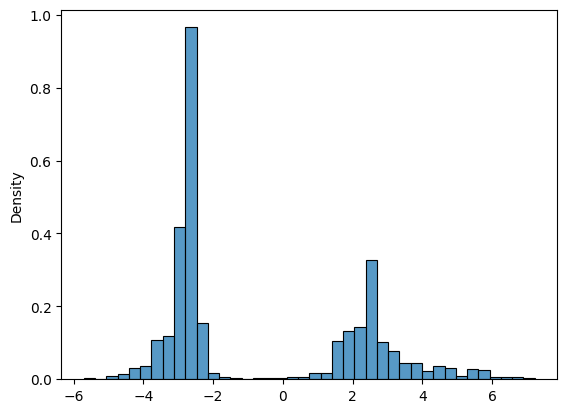

In [0]:
def make_weird_bimodal(n=1000, seed=123):
    rng = np.random.default_rng(seed)

    comp = rng.choice([0, 1], size=n, p=[0.6, 0.4])
    z = np.empty(n)

    # Left mode: tighter and heavier
    z[comp == 0] = rng.normal(-3.2, 0.55, size=(comp == 0).sum())

    # Right mode: wider and slightly farther out
    z[comp == 1] = rng.normal(2.8, 1.25, size=(comp == 1).sum())

    # Mild nonlinear warp
    x = z + 0.5 * np.sin(1.4 * z) + 0.15 * np.sin(3.0 * z)

    return x.reshape(-1, 1)

X = make_weird_bimodal(1000, seed=2025)

sns.histplot(X[:, 0], stat='density', bins=40)
plt.show()

<Axes: ylabel='Count'>

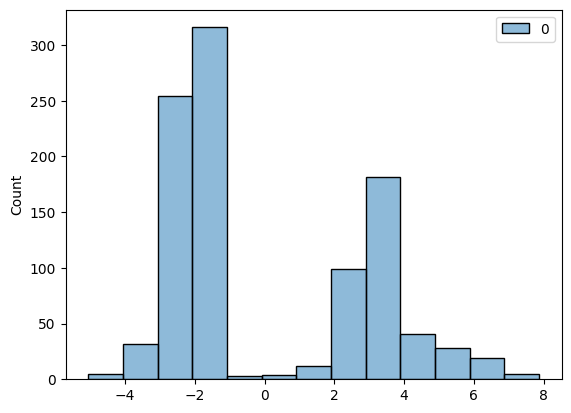

In [0]:
sns.histplot(StandardScaler(with_std=False).fit_transform(X))

## Bimodal

In [0]:
result_bm = tune(
    X.reshape(-1, 1),
    lambdas=np.concatenate([np.array([0]), np.exp(np.linspace(-5, 1, 10))]),
    K=6,
    hidden=6,
    layers=2,
    epoch=1000,
    loc=[-3, 3],
    scale=[1, 1],
    tail_bound=8,
    num_bins=14,
    torch_seed=42
)

lambda: 0.0


Normalizing flow: 100%|██████████| 1000/1000 [01:28<00:00, 11.35it/s]


--- Whitened mode-normality diagnostics (n=1000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 607  test: Jarque-Bera  pvalue: 0.7151
    mode: 1  n: 393  test: Jarque-Bera  pvalue: 0.0202

[1b] Stouffer combined normality p-value
     z = 1.0474
     p = 0.1475
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9682
    CvM p-value: 0.9819
    Q mean:      1.0242  expected approx d=1
    Q max:       17.7632
    min tail p:  2.502e-05
lambda: 0.006737946999085467


Normalizing flow: 100%|██████████| 1000/1000 [01:26<00:00, 11.53it/s]


--- Whitened mode-normality diagnostics (n=1000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 607  test: Jarque-Bera  pvalue: 0.8134
    mode: 1  n: 393  test: Jarque-Bera  pvalue: 0.0213

[1b] Stouffer combined normality p-value
     z = 0.8034
     p = 0.2109
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9911
    CvM p-value: 0.9969
    Q mean:      1.0087  expected approx d=1
    Q max:       17.9130
    min tail p:  2.312e-05
lambda: 0.013123728736940968


Normalizing flow: 100%|██████████| 1000/1000 [01:27<00:00, 11.43it/s]


--- Whitened mode-normality diagnostics (n=1000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 608  test: Jarque-Bera  pvalue: 0.9978
    mode: 1  n: 392  test: Jarque-Bera  pvalue: 0.0162

[1b] Stouffer combined normality p-value
     z = -0.4978
     p = 0.6907
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.7272
    CvM p-value: 0.7095
    Q mean:      0.9950  expected approx d=1
    Q max:       18.0674
    min tail p:  2.132e-05
lambda: 0.025561533206507392


Normalizing flow: 100%|██████████| 1000/1000 [01:26<00:00, 11.50it/s]


--- Whitened mode-normality diagnostics (n=1000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 610  test: Jarque-Bera  pvalue: 0.9937
    mode: 1  n: 390  test: Jarque-Bera  pvalue: 0.0096

[1b] Stouffer combined normality p-value
     z = -0.1072
     p = 0.5427
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.8109
    CvM p-value: 0.8343
    Q mean:      1.0007  expected approx d=1
    Q max:       18.3958
    min tail p:  1.795e-05
Final lambda: 0.0131
Mean test distance: 0.7676
Final weights: [0.5971, 0.4029]
Final means: [array([-2.9934]), array([3.0834])]
Final scales: [array([0.9376]), array([1.1287])]


<Axes: ylabel='Density'>

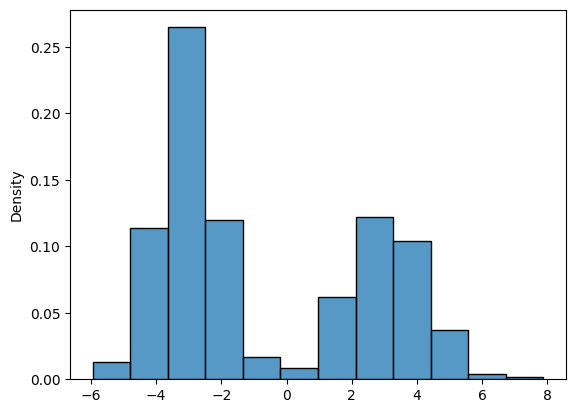

In [0]:
sns.histplot(result_bm['latent'], stat='density')

<Axes: ylabel='Density'>

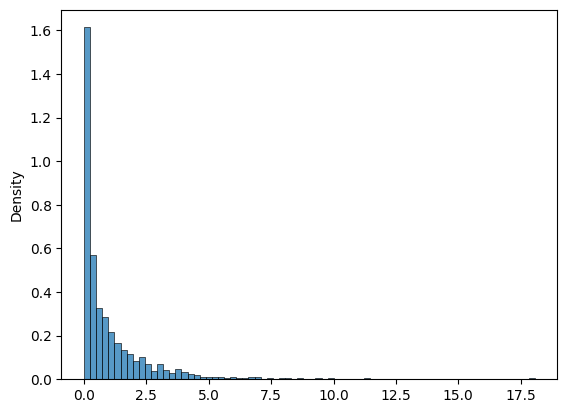

In [0]:
sns.histplot(result_bm['chi_z'], stat='density')

Text(0.5, 1.0, '')

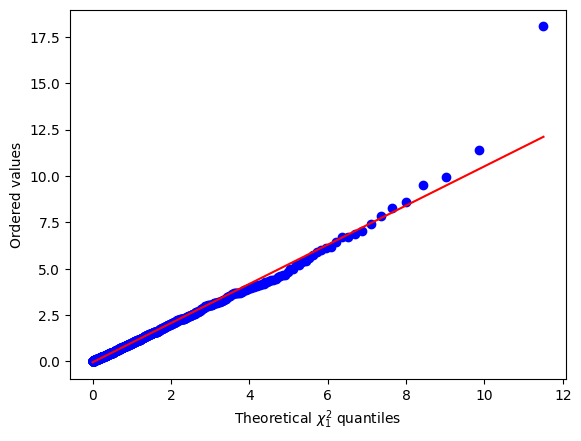

In [0]:
fig, ax = plt.subplots()
stats.probplot(result_bm['chi_z'], dist=stats.chi2, sparams=(1,), plot=ax)
ax.set_xlabel(r"Theoretical $\chi^2_1$ quantiles")
ax.set_ylabel("Ordered values")
ax.set_title(None)

## Unimodal

In [0]:
result_um = tune(
    X.reshape(-1, 1),
    lambdas=np.concatenate([np.array([0]), np.exp(np.linspace(-5, 1, 10))]),
    K=10,
    hidden=10,
    layers=2,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=8,
    num_bins=20,
    torch_seed=42
)

lambda: 0.0


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [02:25<00:00,  6.87it/s]


--- Whitened mode-normality diagnostics (n=1000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 1000  test: Jarque-Bera  pvalue: 0.0734

[1b] Stouffer combined normality p-value
     z = 1.4510
     p = 0.0734
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.4447
    CvM p-value: 0.3600
    Q mean:      1.0440  expected approx d=1
    Q max:       20.7046
    min tail p:  5.359e-06
lambda: 0.006737946999085467


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [02:24<00:00,  6.93it/s]


--- Whitened mode-normality diagnostics (n=1000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 1000  test: Jarque-Bera  pvalue: 0.0833

[1b] Stouffer combined normality p-value
     z = 1.3833
     p = 0.08328
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9227
    CvM p-value: 0.8797
    Q mean:      1.0267  expected approx d=1
    Q max:       20.0061
    min tail p:  7.72e-06
lambda: 0.013123728736940968


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [02:23<00:00,  6.97it/s]


--- Whitened mode-normality diagnostics (n=1000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 1000  test: Jarque-Bera  pvalue: 0.0162

[1b] Stouffer combined normality p-value
     z = 2.1397
     p = 0.01619
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.8586
    CvM p-value: 0.9335
    Q mean:      1.0317  expected approx d=1
    Q max:       20.6576
    min tail p:  5.492e-06
Final lambda: 0.0067
Mean test distance: 4.0480
Final weights: [1.0]
Final means: [array([0.0353])]
Final scales: [array([1.0259])]


<Axes: ylabel='Density'>

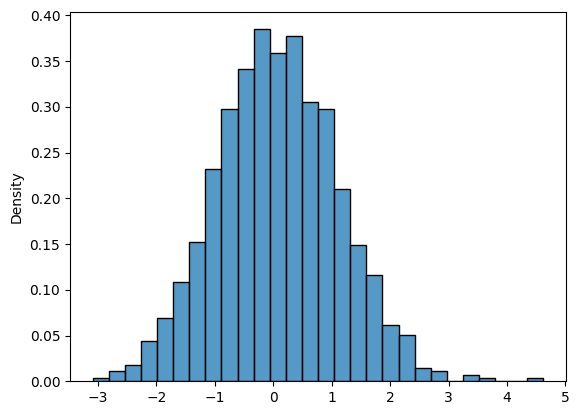

In [0]:
sns.histplot(result_um['latent'], stat='density')

<Axes: ylabel='Density'>

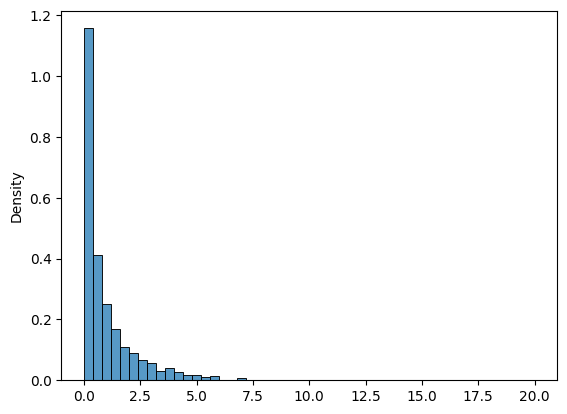

In [0]:
sns.histplot(result_um['chi_z'], stat='density', bins=50)

Text(0.5, 1.0, '')

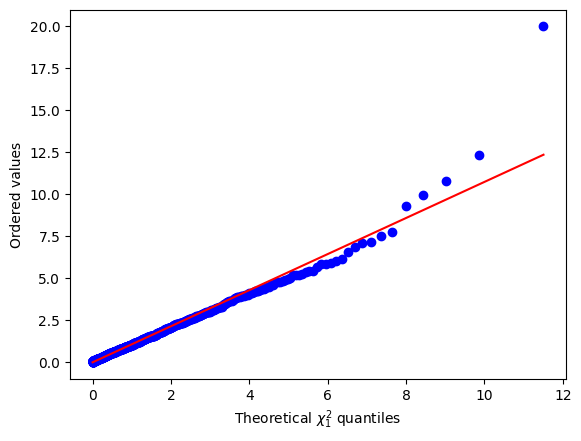

In [0]:
fig, ax = plt.subplots()
stats.probplot(result_um['chi_z'], dist=stats.chi2, sparams=(1,), plot=ax)
ax.set_xlabel(r"Theoretical $\chi^2_1$ quantiles")
ax.set_ylabel("Ordered values")
ax.set_title(None)

## Trimodal

In [0]:
result_tm = tune(
    X.reshape(-1, 1),
    lambdas=np.concatenate([np.array([0]), np.exp(np.linspace(-5, 1, 10))]),
    K=8,
    hidden=8,
    layers=2,
    epoch=1000,
    loc=[-6,0,6],
    scale=[1,1,1],
    tail_bound=8,
    num_bins=32,
    torch_seed=42
)

lambda: 0.0


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [01:58<00:00,  8.47it/s]


--- Whitened mode-normality diagnostics (n=1000, d=1, K=3) ---

[1] Normality by assigned mode
    mode: 0  n: 231  test: Jarque-Bera  pvalue: 0.1077
    mode: 1  n: 380  test: Jarque-Bera  pvalue: 0.9428
    mode: 2  n: 389  test: Jarque-Bera  pvalue: 0.2419

[1b] Stouffer combined normality p-value
     z = 0.2077
     p = 0.4177
     n tests = 3

[2] Pooled Q against chi-square
    KS p-value:  0.9980
    CvM p-value: 0.9958
    Q mean:      0.9591  expected approx d=1
    Q max:       9.0537
    min tail p:  0.002622
lambda: 0.006737946999085467


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [01:55<00:00,  8.69it/s]


--- Whitened mode-normality diagnostics (n=1000, d=1, K=3) ---

[1] Normality by assigned mode
    mode: 0  n: 246  test: Jarque-Bera  pvalue: 0.3164
    mode: 1  n: 366  test: Jarque-Bera  pvalue: 0.3100
    mode: 2  n: 388  test: Jarque-Bera  pvalue: 0.1794

[1b] Stouffer combined normality p-value
     z = 1.0920
     p = 0.1374
     n tests = 3

[2] Pooled Q against chi-square
    KS p-value:  0.9038
    CvM p-value: 0.9506
    Q mean:      0.9660  expected approx d=1
    Q max:       9.3754
    min tail p:  0.002199
lambda: 0.013123728736940968


...

--- Whitened mode-normality diagnostics (n=1000, d=1, K=3) ---

[1] Normality by assigned mode
    mode: 0  n: 212  test: Jarque-Bera  pvalue: 0.1755
    mode: 1  n: 399  test: Jarque-Bera  pvalue: 0.8903
    mode: 2  n: 389  test: Jarque-Bera  pvalue: 0.3228

[1b] Stouffer combined normality p-value
     z = 0.0950
     p = 0.4622
     n tests = 3

[2] Pooled Q against chi-square
    KS p-value:  0.6787
    CvM p-value: 0.7166
    Q mean:      0.9343  expected approx d=1
    Q max:       8.5945
    min tail p:  0.003372
lambda: 0.025561533206507392


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [01:57<00:00,  8.48it/s]


--- Whitened mode-normality diagnostics (n=1000, d=1, K=3) ---

[1] Normality by assigned mode
    mode: 0  n: 204  test: Jarque-Bera  pvalue: 0.0972
    mode: 1  n: 407  test: Jarque-Bera  pvalue: 0.9629
    mode: 2  n: 389  test: Jarque-Bera  pvalue: 0.2914

[1b] Stouffer combined normality p-value
     z = 0.0353
     p = 0.4859
     n tests = 3

[2] Pooled Q against chi-square
    KS p-value:  0.3996
    CvM p-value: 0.3379
    Q mean:      0.9249  expected approx d=1
    Q max:       9.9366
    min tail p:  0.00162
lambda: 0.049787068367863944


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [01:59<00:00,  8.40it/s]

--- Whitened mode-normality diagnostics (n=1000, d=1, K=3) ---

[1] Normality by assigned mode
    mode: 0  n: 154  test: Jarque-Bera  pvalue: 0.3818
    mode: 1  n: 458  test: Jarque-Bera  pvalue: 0.3241
    mode: 2  n: 388  test: Jarque-Bera  pvalue: 0.3647

[1b] Stouffer combined normality p-value
     z = 0.6368
     p = 0.2621
     n tests = 3

[2] Pooled Q against chi-square
    KS p-value:  0.0988
    CvM p-value: 0.0404
    Q mean:      0.8920  expected approx d=1
    Q max:       9.4535
    min tail p:  0.002108
Final lambda: 0.0256
Mean test distance: 5.8053
Final weights: [0.2415, 0.3845, 0.3739]
Final means: [array([-5.7062]), array([-0.0263]), array([5.9202])]
Final scales: [array([1.114]), array([0.953]), array([0.9328])]


<Axes: ylabel='Density'>

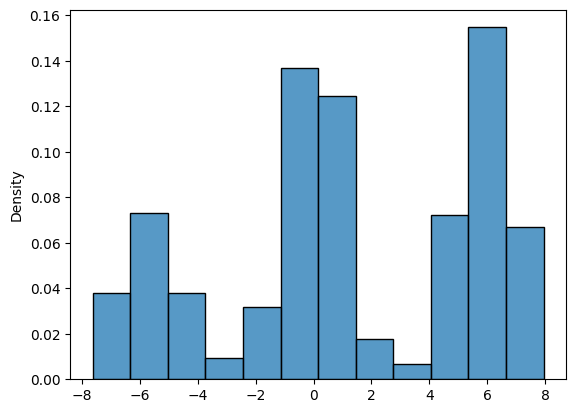

In [0]:
sns.histplot(result_tm['latent'], stat='density')

<Axes: ylabel='Density'>

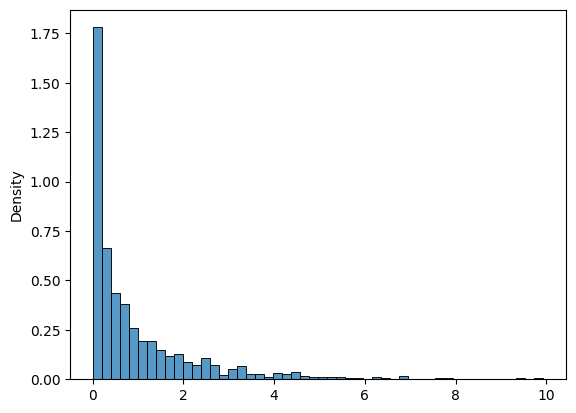

In [0]:
sns.histplot(result_tm['chi_z'], stat='density', bins=50)

Text(0.5, 1.0, '')

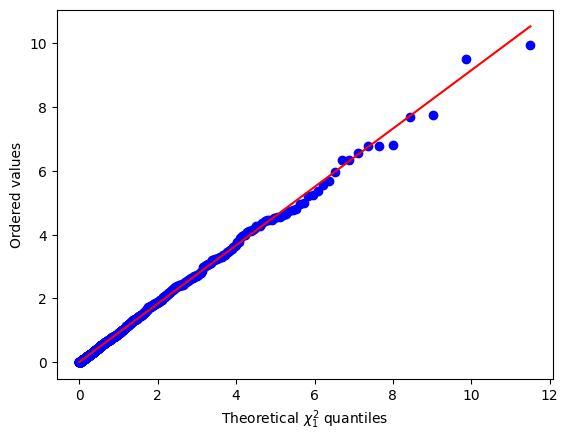

In [0]:
fig, ax = plt.subplots()
stats.probplot(result_tm['chi_z'], dist=stats.chi2, sparams=(1,), plot=ax)
ax.set_xlabel(r"Theoretical $\chi^2_1$ quantiles")
ax.set_ylabel("Ordered values")
ax.set_title(None)

In [0]:
select_flow_by_transport_modes([result_um, result_bm, result_tm])

{'selected_index': 1,
 'table': [{'index': 0,
   'M': 4.047974109649658,
   'n_modes': 1,
   'K_m': 2,
   'rho': 0.3662040962227033,
   'score': 4.780382302095065},
  {'index': 1,
   'M': 0.7676167488098145,
   'n_modes': 2,
   'K_m': 5,
   'rho': 0.3662040962227033,
   'score': 2.598637229923331},
  {'index': 2,
   'M': 5.8052544593811035,
   'n_modes': 3,
   'K_m': 8,
   'rho': 0.3662040962227033,
   'score': 8.73488722916273}]}